In [23]:
import numpy as np #import library
from math import ceil
from scipy import stats
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

limit=1000000 #limit under which we look for primes

primes_long = pd.read_csv("/Users/admin/Downloads/numbers.csv") #opens the list of all primes we are looking for
primes_long["value"] = pd.to_numeric(primes_long["value"]).astype(int) #converts numbers to integers
primes = primes_long[primes_long["value"] < limit]['value'].tolist() #cuts the list to the required limit

#finds twin primes in list of all primes
def find_sexy_primes(primes):
    prime_set = set(primes)
    return [(p, p + 6) for p in primes if (p + 6) in prime_set]


sexy_starts=find_sexy_primes(primes) #finds the smallest twin in pair


def calculate_bin_size(sexy_starts): #calculates the bin size, so that there are at least 5 primes in a bin
  min_counts_per_bin=5
  sorted_sexy = sorted([p for p, _ in sexy_starts])
  bin_size=0
  for i in range(len(sorted_sexy) - min_counts_per_bin):
    current_gap = sorted_sexy[i + min_counts_per_bin] - sorted_sexy[i]
        
    if current_gap > bin_size:
      bin_size= current_gap       
  return ceil(bin_size)



 
#sorts twin primes in bins
def count_primes_in_bins (sexy_starts, num_bins, bin_size): 
    bin_labels = [] #range if each bin
    twin_prime_counts = [] #how many twin primes in the bin
  
 
    for i in range(num_bins):
        lo = 2 if i==0 else i * bin_size #lower bin limit
        hi = (i + 1) * bin_size #higher bin limit
        twin_prime_counts.append(sum(1 for p, _ in sexy_starts if lo <= p <= hi))
        bin_labels.append(f"{lo}-{hi}")
    observed_values=twin_prime_counts
 
    return bin_labels, observed_values

#Hardy-Littlewood Conjecture
#sorts expected data in bins
def hardy_littlewood_conjecture(num_bins, bin_size):
  C2=1.32032
  expected_values=[]
  
  def integrand(t): #function inside integral
    return 1/(np.log(t)**2)
  
  
  for i in range (num_bins): #calculates the area under the curve for each bin
    lo=2 if i==0 else i*bin_size
    hi=(i+1)* bin_size
   
    area,_=quad(integrand,lo, hi)
    expected=2*C2*area
    expected_values.append(expected)
  return expected_values

#Goodnes of fit test
def chi_square_goodness_of_fit(observed_values, expected_values):
  statistic=0
  significance_level=0.05 
  for i in range (len(observed_values)): #loops through the prime number values
    statistic=statistic+(np.square(observed_values[i]-expected_values[i])/expected_values[i]) #chi squared statistic formula

  df=len(observed_values)-1
  p_value=stats.chi2.sf(statistic, df) #calculates p_value
  print(f"Chi-square statistic: {statistic:.4f}, p-value: {p_value:.4f}, df: {df}")
  if p_value>significance_level:
    print("Fail to reject H0")
  else:
    print("Reject H0")


bin_size=calculate_bin_size(sexy_starts)
num_bins = ceil(limit/bin_size)
labels, observed_values = count_primes_in_bins(sexy_starts, num_bins, bin_size)
for i in range(num_bins):
    print(f"Bin {labels[i]}: {observed_values[i]} sexy primes")

expected_values=hardy_littlewood_conjecture(num_bins, bin_size)

print("H0= there is no significant difference between the distribution of sexy primes and Hardy-Littlewood Conjecture ")
print("H1= there is significant difference between the distribution of sexy primes and Hardy-Littlewood Conjecture ")
chi_square_goodness_of_fit(observed_values, expected_values)


Bin 2-1208: 85 sexy primes
Bin 1208-2416: 63 sexy primes
Bin 2416-3624: 42 sexy primes
Bin 3624-4832: 45 sexy primes
Bin 4832-6040: 50 sexy primes
Bin 6040-7248: 40 sexy primes
Bin 7248-8456: 34 sexy primes
Bin 8456-9664: 43 sexy primes
Bin 9664-10872: 31 sexy primes
Bin 10872-12080: 31 sexy primes
Bin 12080-13288: 40 sexy primes
Bin 13288-14496: 28 sexy primes
Bin 14496-15704: 33 sexy primes
Bin 15704-16912: 41 sexy primes
Bin 16912-18120: 33 sexy primes
Bin 18120-19328: 29 sexy primes
Bin 19328-20536: 38 sexy primes
Bin 20536-21744: 32 sexy primes
Bin 21744-22952: 30 sexy primes
Bin 22952-24160: 41 sexy primes
Bin 24160-25368: 25 sexy primes
Bin 25368-26576: 27 sexy primes
Bin 26576-27784: 36 sexy primes
Bin 27784-28992: 29 sexy primes
Bin 28992-30200: 32 sexy primes
Bin 30200-31408: 33 sexy primes
Bin 31408-32616: 31 sexy primes
Bin 32616-33824: 29 sexy primes
Bin 33824-35032: 28 sexy primes
Bin 35032-36240: 30 sexy primes
Bin 36240-37448: 28 sexy primes
Bin 37448-38656: 27 sexy pri

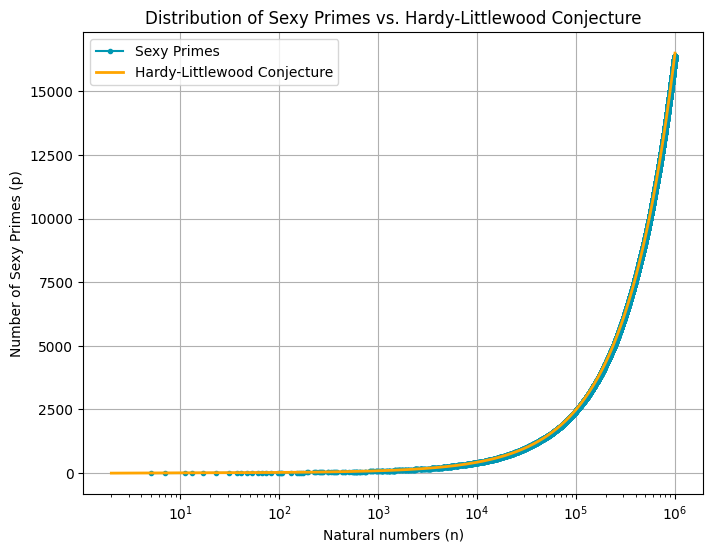

In [24]:
# Twin Prime Visualization
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


def hardy_littlewood_conjecture(x):
    C2=1.32032

    def integrand(t): #function inside integral
        return 1/(np.log(t)**2)
   
    area,_=quad(integrand,2, x)
    expected=2*C2*area
    return expected

# smooth x values from 2 to limit on a log scale
x_hl = np.logspace(np.log10(2), np.log10(limit), 500)
y_hl = [hardy_littlewood_conjecture(x) for x in x_hl]

xp = [p for p, _ in sexy_starts]
yp= range(1, len(xp)+1)
# The circular prime list supplemented with R19 and R23 and the number of primes list (just the length of xp)
plt.figure(figsize=(8,6))
plt.xscale('log')
#plt.yscale('log')
plt.title('Distribution of Sexy Primes vs. Hardy-Littlewood Conjecture')
plt.xticks([1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
plt.xlabel('Natural numbers (n)')
plt.ylabel('Number of Sexy Primes (p)')
plt.plot(xp,yp, marker='.', label='Sexy Primes', color='#0097b2')
plt.plot(x_hl, y_hl, label='Hardy-Littlewood Conjecture', color='orange', linewidth=2)
plt.legend()
plt.grid('0')
# Scaling customizing and adding extra information
plt.show()